# Final Project: Sleep Health & Lifestyle Dataset

### Objective: 

For this course project, I will build a sleep disorder classification model using the Sleep and Lifestyle Study Dataset from Kaggle,
training and comparing a Random Forest Classifier and an XGBoost model across the
dataset’s patient features. The goal is to predict whether a
patient has no sleep disorder, insomnia, or sleep apnea, evaluated using accuracy, F1-
score, ROC-AUC, and per-class precision-recall metrics. Both models will be audited using fairness metrics to ensure equal representation across demographics. 

## Basic Info & Cleaning 

In [4]:
import pandas as pd

df = pd.read_csv('./data/Sleep_health_and_lifestyle_dataset (Copy).csv')

print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}\n")
print(df.info())

Dataset Overview:
Total samples: 374

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

In [5]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 
                           'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False)

print("Missing Values Analysis:")
display(missing_df)

Missing Values Analysis:


,Missing Values,Percentage (%)
Sleep Disorder,219,58.55615


In [6]:
# Handling missing values
# Fill missing values in Sleep Disorder with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['Has_Sleep_Disorder'] = df['Sleep Disorder'].apply(lambda x: 0 if x == 'None' else 1)

# Convert categorical variables
# Extract systolic and diastolic BP
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# Encode gender
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [7]:
# Check for duplicates
print("-" * 50)
print(f"Duplicate entries: {df.duplicated().sum()}")

--------------------------------------------------
Duplicate entries: 0


In [8]:
# Checking for missing values after modification
missing_values = df.isnull().sum()

display(missing_values)

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Has_Sleep_Disorder         0
Systolic                   0
Diastolic                  0
Gender_Encoded             0
dtype: int64

In [9]:
print(f'Disorder distribution: {df["Sleep Disorder"].value_counts().to_dict()}')

Disorder distribution: {'None': 219, 'Sleep Apnea': 78, 'Insomnia': 77}


## Exploratory Data Analysis

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for matplotlib
plt.style.use('default')
sns.set_palette("husl")

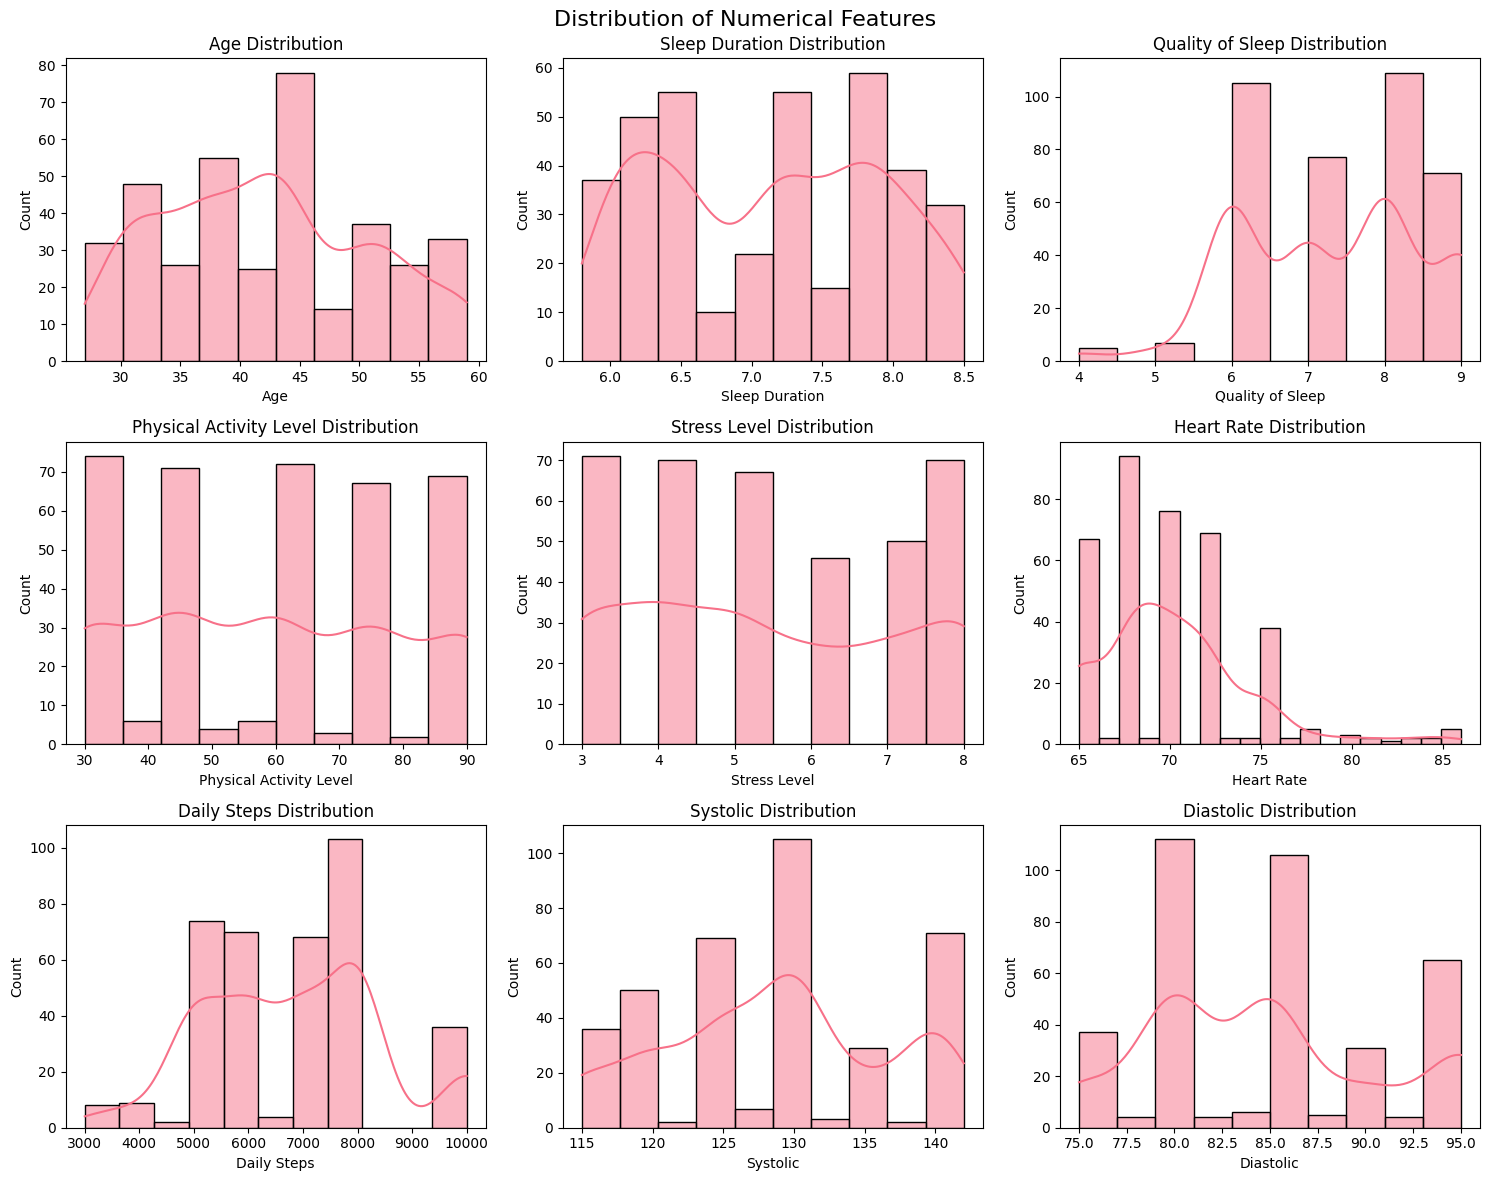

In [11]:
# Distribution of numerical features
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

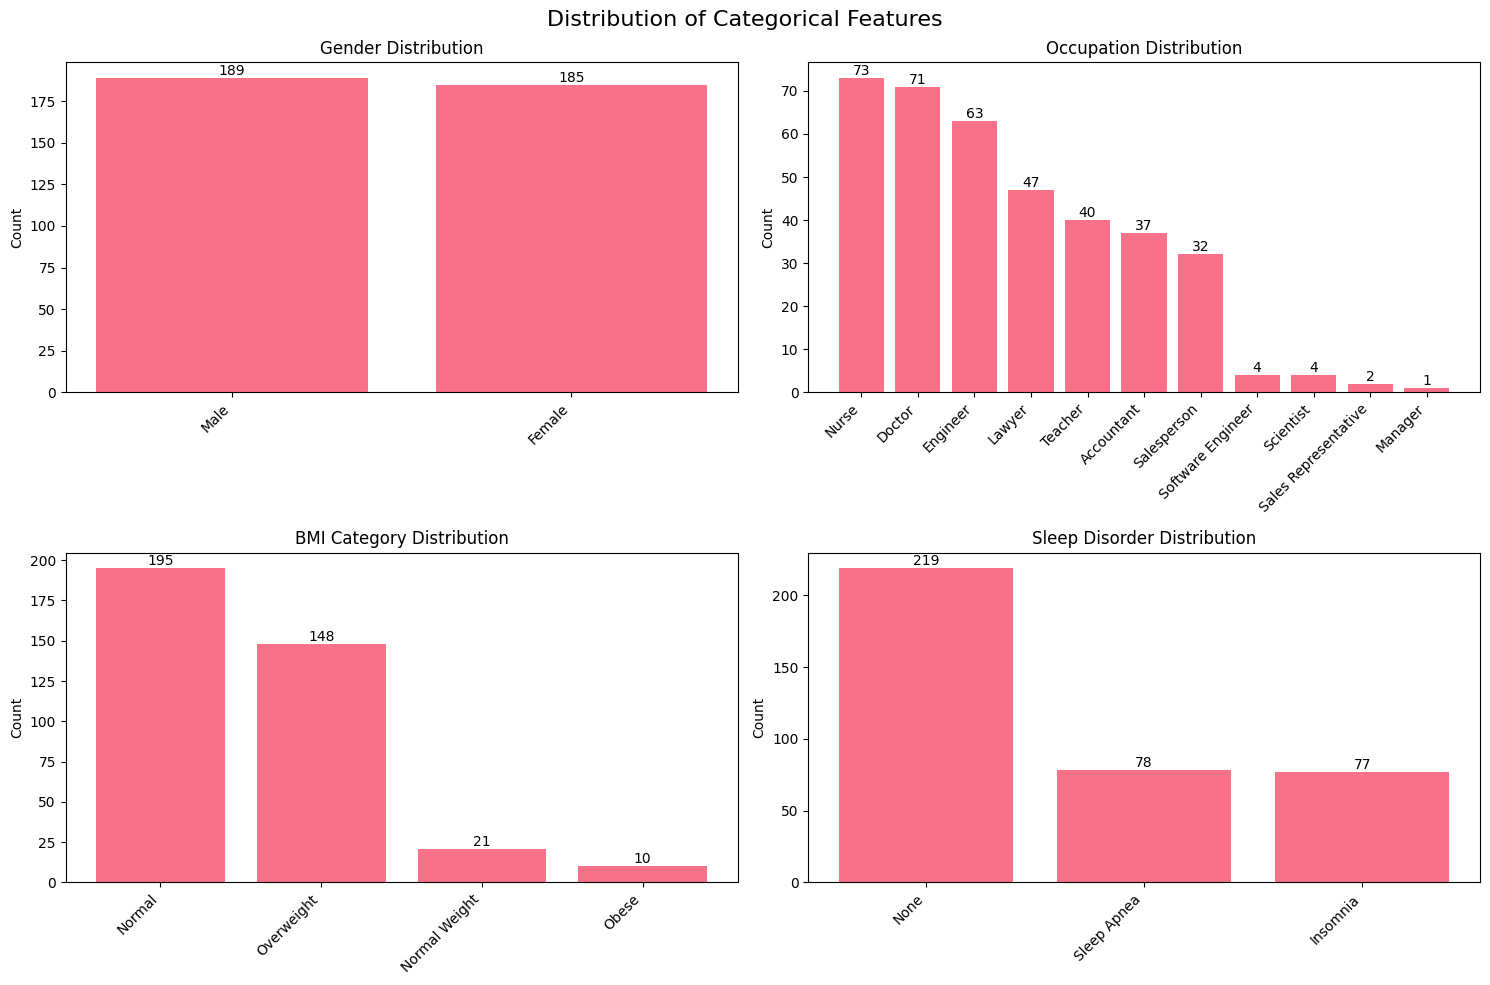

In [12]:
# Categorical features distribution
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16)

for i, col in enumerate(categorical_cols):
    ax = axes[i//2, i%2]
    value_counts = df[col].value_counts()
    ax.bar(range(len(value_counts)), value_counts.values)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Count')

plt.tight_layout()

for i, col in enumerate(categorical_cols):
    ax = axes[i//2, i%2]
    for j, bar in enumerate(ax.patches):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
plt.show()

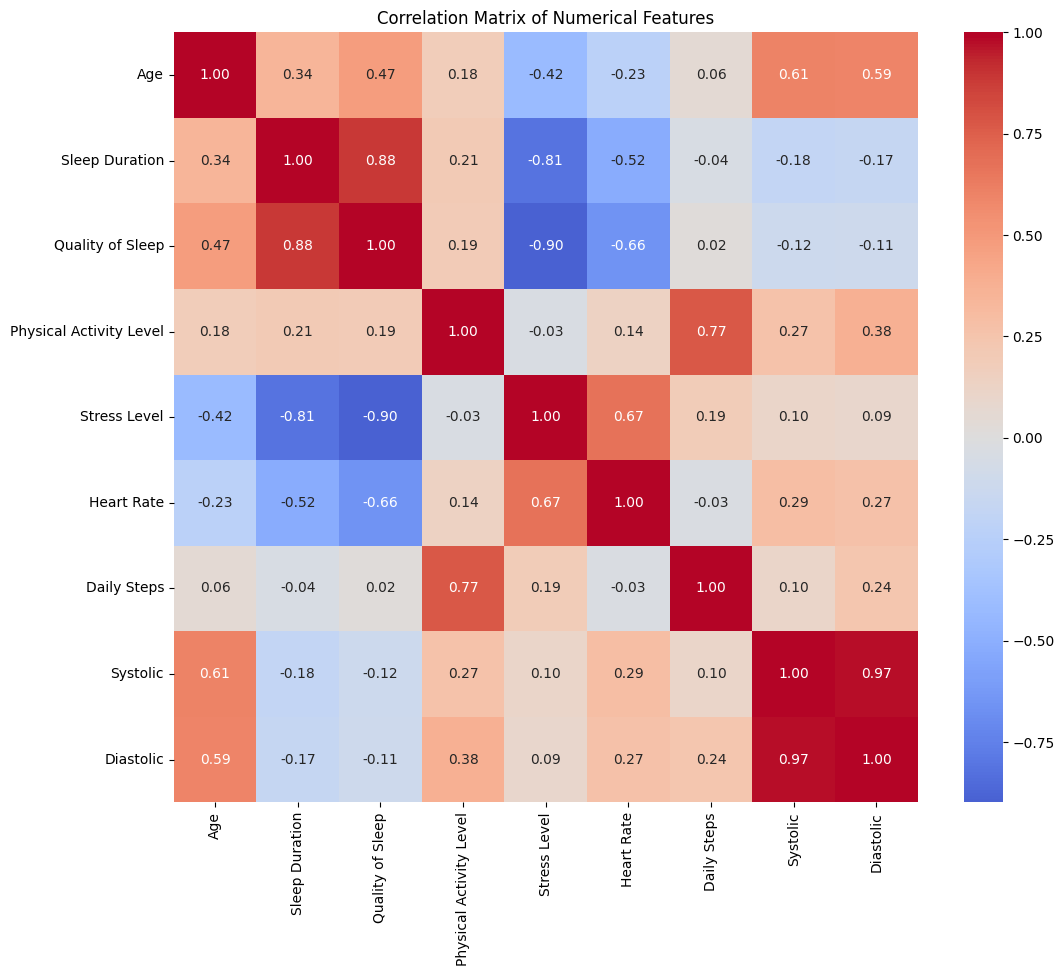

In [13]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

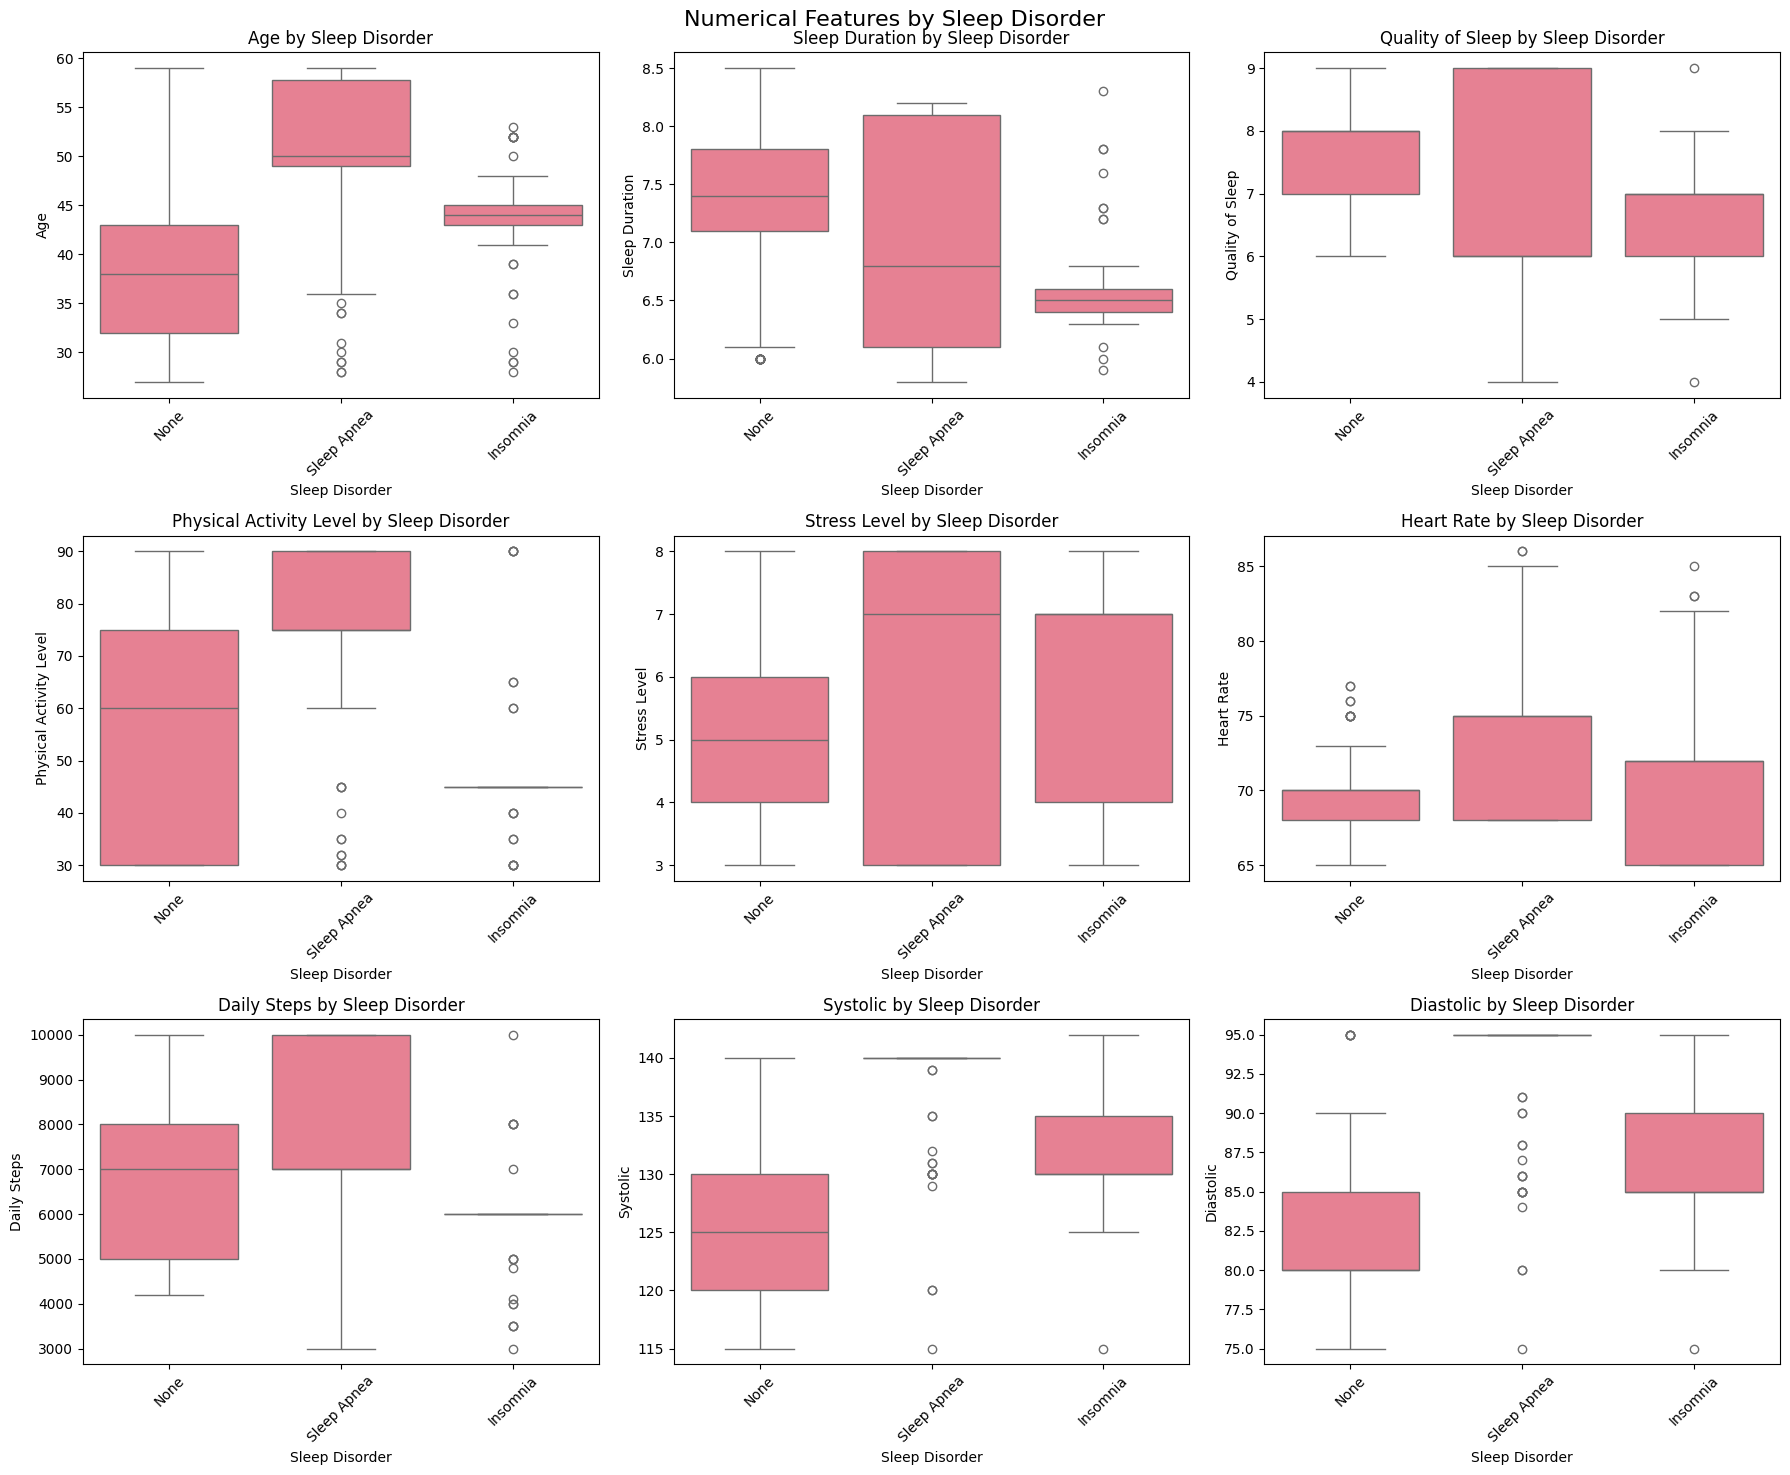

In [14]:
# Box plots of numerical features by Sleep Disorder
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Numerical Features by Sleep Disorder', fontsize=16)

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df, x='Sleep Disorder', y=col, ax=ax)
    ax.set_title(f'{col} by Sleep Disorder')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

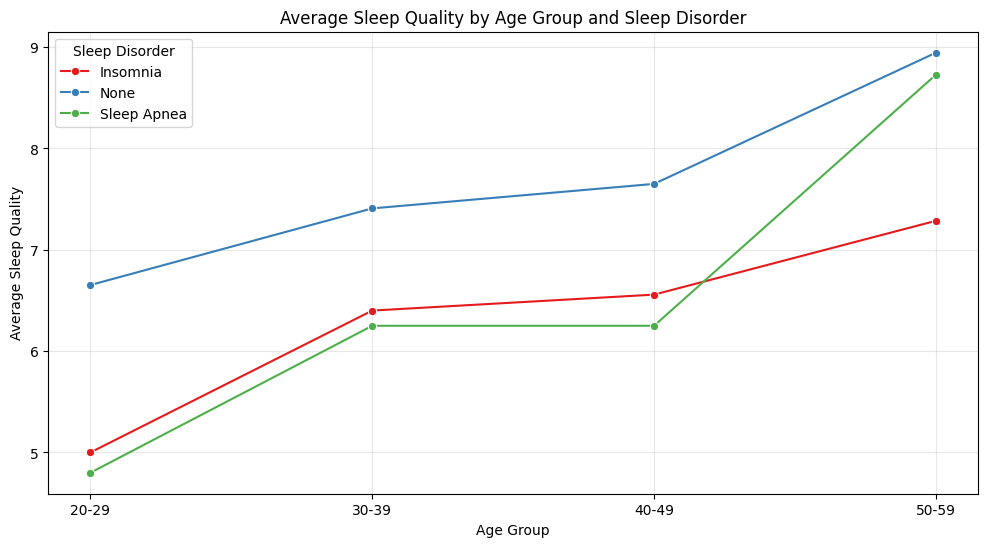

In [15]:
# Line plot: Average Sleep Quality by Age Group and Sleep Disorder
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-29', '30-39', '40-49', '50-59'])

avg_quality_by_age_disorder = df.groupby(['Age_Group', 'Sleep Disorder'])['Quality of Sleep'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_quality_by_age_disorder, x='Age_Group', y='Quality of Sleep', hue='Sleep Disorder', marker='o', palette='Set1')
plt.title('Average Sleep Quality by Age Group and Sleep Disorder')
plt.xlabel('Age Group')
plt.ylabel('Average Sleep Quality')
plt.legend(title='Sleep Disorder')
plt.grid(True, alpha=0.3)
plt.show()

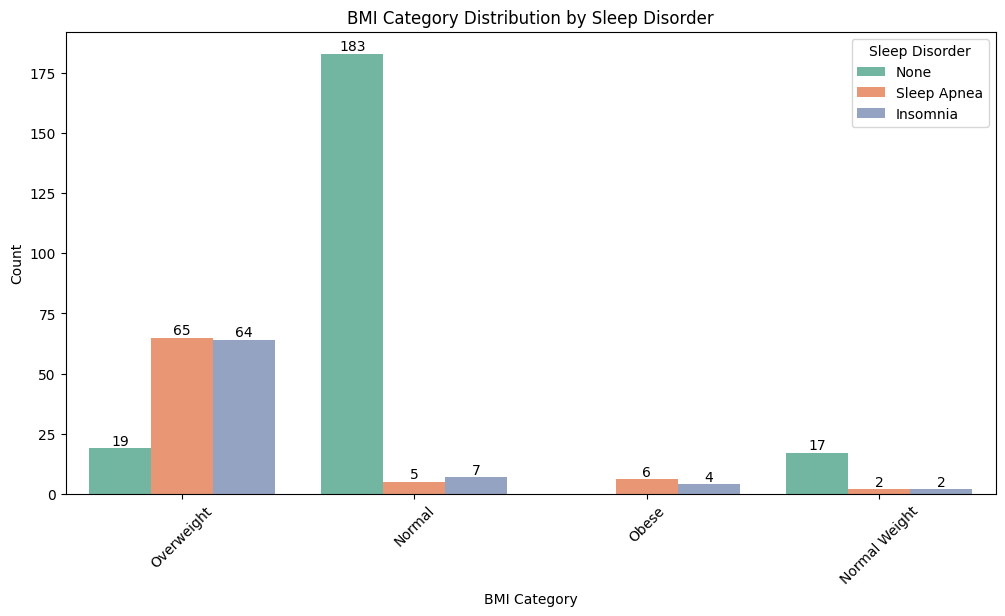

In [16]:
# BMI Category distribution by Sleep Disorder
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='BMI Category', hue='Sleep Disorder', palette='Set2')
plt.title('BMI Category Distribution by Sleep Disorder')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.xticks(rotation=45)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.show()

## RFC and XGBOOST Model Comparison

In [19]:
# Sleep Disorder Classification Model - Random Forest vs XGBoost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             precision_recall_curve, auc, classification_report,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Prepare the data
X = df.copy()
y = X.pop('Sleep Disorder')

# Handle missing values if any
X = X.fillna(X.mean(numeric_only=True))

# Encode the target variable
label_encoder_target = LabelEncoder()
y_encoded = label_encoder_target.fit_transform(y)
print(f"Target classes: {label_encoder_target.classes_}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}\n")

# Encode categorical features
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Parse Blood Pressure into systolic and diastolic
X[['Systolic', 'Diastolic']] = X['Blood Pressure'].str.split('/', expand=True).astype(int)
X = X.drop('Blood Pressure', axis=1)

# Remove non-numeric columns that shouldn't be in the model
X = X.drop(['Person ID', 'Age_Group'], axis=1)

print(f"\nFeatures used: {X.columns.tolist()}")
print(f"Feature shape: {X.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}\n")

# ============= RANDOM FOREST CLASSIFIER =============
print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_pred_train = rf_model.predict(X_train_scaled)
rf_pred_test = rf_model.predict(X_test_scaled)
rf_pred_proba_test = rf_model.predict_proba(X_test_scaled)

# Random Forest metrics
print("\nRandom Forest - Training Metrics:")
print(f"Accuracy: {accuracy_score(y_train, rf_pred_train):.4f}")
print(f"F1-Score (weighted): {f1_score(y_train, rf_pred_train, average='weighted', zero_division=0):.4f}")

print("\nRandom Forest - Test Metrics:")
rf_accuracy = accuracy_score(y_test, rf_pred_test)
rf_f1 = f1_score(y_test, rf_pred_test, average='weighted', zero_division=0)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-Score (weighted): {rf_f1:.4f}")

# ROC-AUC for multiclass
try:
    rf_roc_auc = roc_auc_score(y_test, rf_pred_proba_test, multi_class='ovr', zero_division=0)
    print(f"ROC-AUC (One-vs-Rest): {rf_roc_auc:.4f}")
except Exception as e:
    print(f"ROC-AUC calculation: {str(e)}")
    rf_roc_auc = None

# Per-class precision-recall metrics
print("\nRandom Forest - Per-Class Precision-Recall Metrics:")
print(classification_report(y_test, rf_pred_test, target_names=label_encoder_target.classes_))

# ============= XGBOOST CLASSIFIER =============
print("\n" + "=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_pred_train = xgb_model.predict(X_train_scaled)
xgb_pred_test = xgb_model.predict(X_test_scaled)
xgb_pred_proba_test = xgb_model.predict_proba(X_test_scaled)

# XGBoost metrics
print("\nXGBoost - Training Metrics:")
print(f"Accuracy: {accuracy_score(y_train, xgb_pred_train):.4f}")
print(f"F1-Score (weighted): {f1_score(y_train, xgb_pred_train, average='weighted', zero_division=0):.4f}")

print("\nXGBoost - Test Metrics:")
xgb_accuracy = accuracy_score(y_test, xgb_pred_test)
xgb_f1 = f1_score(y_test, xgb_pred_test, average='weighted', zero_division=0)
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"F1-Score (weighted): {xgb_f1:.4f}")

# ROC-AUC for multiclass
try:
    xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba_test, multi_class='ovr', zero_division=0)
    print(f"ROC-AUC (One-vs-Rest): {xgb_roc_auc:.4f}")
except Exception as e:
    print(f"ROC-AUC calculation: {str(e)}")
    xgb_roc_auc = None

# Per-class precision-recall metrics
print("\nXGBoost - Per-Class Precision-Recall Metrics:")
print(classification_report(y_test, xgb_pred_test, target_names=label_encoder_target.classes_))

# ============= MODEL COMPARISON =============
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (weighted)', 'ROC-AUC (OvR)'],
    'Random Forest': [
        f"{rf_accuracy:.4f}",
        f"{rf_f1:.4f}",
        f"{rf_roc_auc:.4f}" if rf_roc_auc else "N/A"
    ],
    'XGBoost': [
        f"{xgb_accuracy:.4f}",
        f"{xgb_f1:.4f}",
        f"{xgb_roc_auc:.4f}" if xgb_roc_auc else "N/A"
    ]
})

print("\n" + comparison_df.to_string(index=False))


Target classes: ['Insomnia' 'None' 'Sleep Apnea']
Class distribution:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
Occupation encoding: {'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Nurse': np.int64(5), 'Sales Representative': np.int64(6), 'Salesperson': np.int64(7), 'Scientist': np.int64(8), 'Software Engineer': np.int64(9), 'Teacher': np.int64(10)}
BMI Category encoding: {'Normal': np.int64(0), 'Normal Weight': np.int64(1), 'Obese': np.int64(2), 'Overweight': np.int64(3)}

Features used: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Has_Sleep_Disorder', 'Systolic', 'Diastolic', 'Gender_Encoded']
Feature shape: (374, 14)

Training set size: (299, 14)
Test set size: (75, 14)

RANDOM F

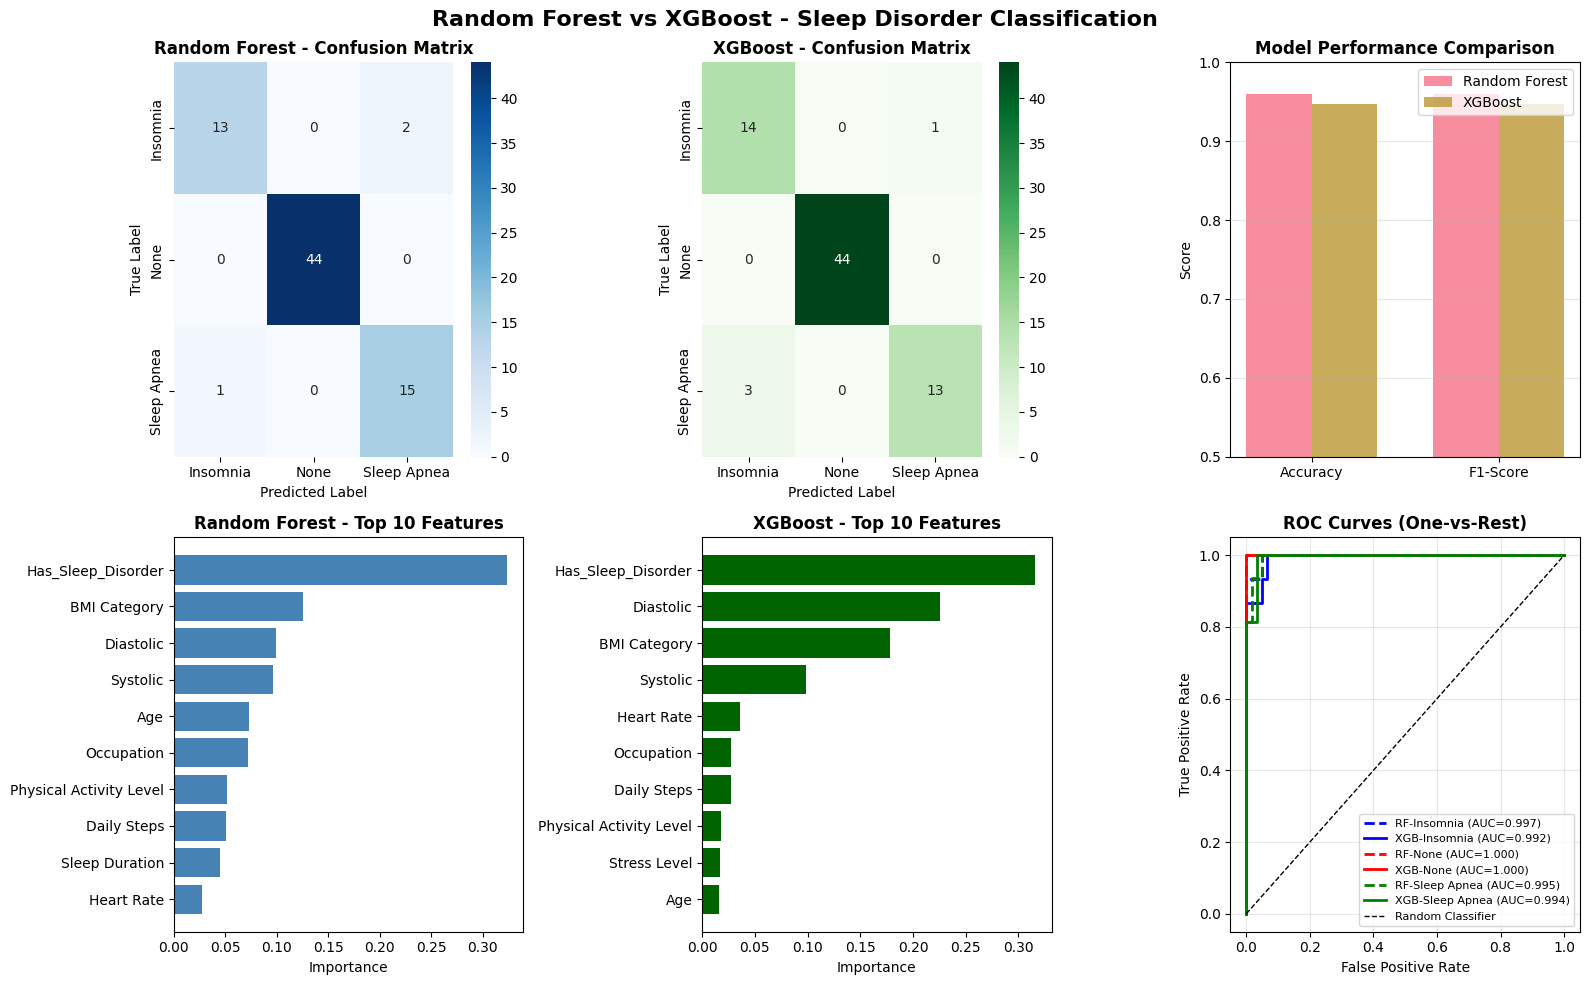


Model comparison complete!


In [20]:
# ============= VISUALIZATIONS =============
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Random Forest vs XGBoost - Sleep Disorder Classification', fontsize=16, fontweight='bold')

# Confusion Matrices
rf_cm = confusion_matrix(y_test, rf_pred_test)
xgb_cm = confusion_matrix(y_test, xgb_pred_test)

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=label_encoder_target.classes_,
            yticklabels=label_encoder_target.classes_)
axes[0, 0].set_title('Random Forest - Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=label_encoder_target.classes_,
            yticklabels=label_encoder_target.classes_)
axes[0, 1].set_title('XGBoost - Confusion Matrix', fontweight='bold')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Metric Comparison
metrics_names = ['Accuracy', 'F1-Score']
rf_metrics = [rf_accuracy, rf_f1]
xgb_metrics = [xgb_accuracy, xgb_f1]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 2].bar(x - width/2, rf_metrics, width, label='Random Forest', alpha=0.8)
axes[0, 2].bar(x + width/2, xgb_metrics, width, label='XGBoost', alpha=0.8)
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Model Performance Comparison', fontweight='bold')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(metrics_names)
axes[0, 2].legend()
axes[0, 2].set_ylim([0.5, 1.0])
axes[0, 2].grid(axis='y', alpha=0.3)

# Feature Importance - Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[1, 0].barh(rf_feature_importance['feature'], rf_feature_importance['importance'], color='steelblue')
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Random Forest - Top 10 Features', fontweight='bold')
axes[1, 0].invert_yaxis()

# Feature Importance - XGBoost
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[1, 1].barh(xgb_feature_importance['feature'], xgb_feature_importance['importance'], color='darkgreen')
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('XGBoost - Top 10 Features', fontweight='bold')
axes[1, 1].invert_yaxis()

# ROC Curves for each class
ax_roc = axes[1, 2]
colors = ['blue', 'red', 'green']

for i, class_name in enumerate(label_encoder_target.classes_):
    # Create binary classification for this class
    y_test_binary = (y_test == i).astype(int)
    
    # Random Forest ROC curve
    rf_fpr, rf_tpr, _ = roc_curve(y_test_binary, rf_pred_proba_test[:, i])
    rf_auc = auc(rf_fpr, rf_tpr)
    ax_roc.plot(rf_fpr, rf_tpr, color=colors[i], linestyle='--', 
                label=f'RF-{class_name} (AUC={rf_auc:.3f})', linewidth=2)
    
    # XGBoost ROC curve
    xgb_fpr, xgb_tpr, _ = roc_curve(y_test_binary, xgb_pred_proba_test[:, i])
    xgb_auc = auc(xgb_fpr, xgb_tpr)
    ax_roc.plot(xgb_fpr, xgb_tpr, color=colors[i], linestyle='-',
                label=f'XGB-{class_name} (AUC={xgb_auc:.3f})', linewidth=2)

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves (One-vs-Rest)', fontweight='bold')
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Model comparison complete!")
print("=" * 60)